# Validação 21 — Auditoria das fontes científicas

## tl;dr

Este notebook consulta de forma limitada todas as fontes sugeridas pelo grupo e registra o papel correto de cada uma. Ele testa **acesso e capacidade técnica**, não compara qualidade científica nem trata resultados duplicados como estudos independentes.

A consulta controlada é `coffee prostate cancer`, coerente com o estudo de caso da EDA. Plataformas que exigem credenciais são registradas sem tentar contornar o acesso; Google Acadêmico permanece manual por não possuir uma API pública suportada no projeto.

## Context & Methods

### Key Assumptions

- PubMed, OpenAlex e SciELO são candidatos de descoberta, mas seus catálogos se sobrepõem.
- PMC fornece conteúdo; ClinicalTrials.gov, Crossref, Retraction Watch e DataCite validam ou enriquecem artigos.
- ScienceDirect, Springer Nature e Nature são plataformas editoriais, não confirmações independentes.
- As contagens retornadas não são comparáveis: cada API possui indexação, semântica e filtros próprios.
- SciELO é testado pelo catálogo ArticleMeta; este endpoint não realiza a busca temática usada nas demais fontes.

Consultas pequenas reduzem carga externa e tornam a auditoria repetível.

In [1]:
from collections import Counter
from html import escape
import os
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from dotenv import load_dotenv
from IPython.display import HTML, Markdown, display

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
load_dotenv(project_root / ".env")

from fatofake import (
    AcademicSourceAuditor,
    SourceAuditConfig,
    SourceProbeStatus,
    SourceRole,
)

QUERY = "coffee prostate cancer"
LIMIT = 5
print(f"Consulta: {QUERY!r} | limite por amostra: {LIMIT}")

Consulta: 'coffee prostate cancer' | limite por amostra: 5


## Data

### 1. Executar as consultas oficiais

As chaves são lidas apenas do `.env` e nunca são exibidas. Sem `SPRINGER_API_KEY` ou `ELSEVIER_API_KEY`, o resultado correto é `CREDENTIAL_REQUIRED`.

In [2]:
config = SourceAuditConfig(
    query=QUERY,
    limit=LIMIT,
    email=os.getenv("NCBI_EMAIL") or None,
    ncbi_api_key=os.getenv("NCBI_API_KEY") or None,
    springer_api_key=os.getenv("SPRINGER_API_KEY") or None,
    elsevier_api_key=os.getenv("ELSEVIER_API_KEY") or None,
)
report = AcademicSourceAuditor(timeout=30).audit(config)
print(f"Fontes classificadas: {len(report.results)} | disponíveis: {report.available_count} | erros: {report.error_count}")

Fontes classificadas: 12 | disponíveis: 8 | erros: 0


### 2. Exibir o resultado auditável

`Específica` indica se o número pertence à consulta temática. Resultados de disponibilidade global, como o catálogo de retratações e o catálogo SciELO, não devem ser interpretados como artigos sobre café e câncer de próstata.

In [3]:
rows = []
for item in report.results:
    count = "—" if item.result_count is None else f"{item.result_count:,}".replace(",", ".")
    rows.append(
        "<tr>"
        f"<td>{escape(item.source)}</td>"
        f"<td>{item.role.value}</td>"
        f"<td>{item.status.value}</td>"
        f"<td>{count}</td>"
        f"<td>{'Sim' if item.query_specific else 'Não'}</td>"
        f"<td>{escape(item.detail)}</td>"
        "</tr>"
    )

display(HTML(
    "<table><thead><tr>"
    "<th>Fonte</th><th>Papel</th><th>Status</th><th>Contagem informada</th>"
    "<th>Específica</th><th>Interpretação</th>"
    "</tr></thead><tbody>" + "".join(rows) + "</tbody></table>"
))

Fonte,Papel,Status,Contagem informada,Específica,Interpretação
PubMed,DISCOVERY,AVAILABLE,150,Sim,Busca temática; 5 registros recuperados na amostra.
PubMed Central (PMC),CONTENT,AVAILABLE,4,Sim,4 de 5 PMIDs da amostra possuem PMCID.
ClinicalTrials.gov,VALIDATION,AVAILABLE,4,Sim,Busca de registros; 4 estudos recuperados na amostra.
Crossref,VALIDATION,AVAILABLE,3.290.330,Sim,Busca de metadados; 5 registros recuperados na amostra.
Retraction Watch (via Crossref),VALIDATION,AVAILABLE,75.817,Não,Teste de disponibilidade do catálogo de retratações; a checagem real é por DOI.
OpenAlex,DISCOVERY,AVAILABLE,15.042,Sim,Busca temática; 5 trabalhos recuperados na amostra.
DataCite,VALIDATION,AVAILABLE,26,Sim,Busca de objetos de pesquisa; 5 registros recuperados na amostra.
SciELO,DISCOVERY,AVAILABLE,565.236,Não,"O ArticleMeta respondeu, mas este endpoint testa o catálogo brasileiro, não busca temática."
Springer Nature,PUBLISHER,CREDENTIAL_REQUIRED,—,Sim,A API de metadados exige chave; nenhum conteúdo foi consultado.
ScienceDirect,PUBLISHER,CREDENTIAL_REQUIRED,—,Sim,A API da Elsevier exige chave; nenhum conteúdo foi consultado.


## Results

### 3. Resumir os estados de integração

O gráfico mostra quantas fontes ficaram em cada estado técnico. Ele não mede relevância, cobertura bibliográfica nem qualidade dos artigos.

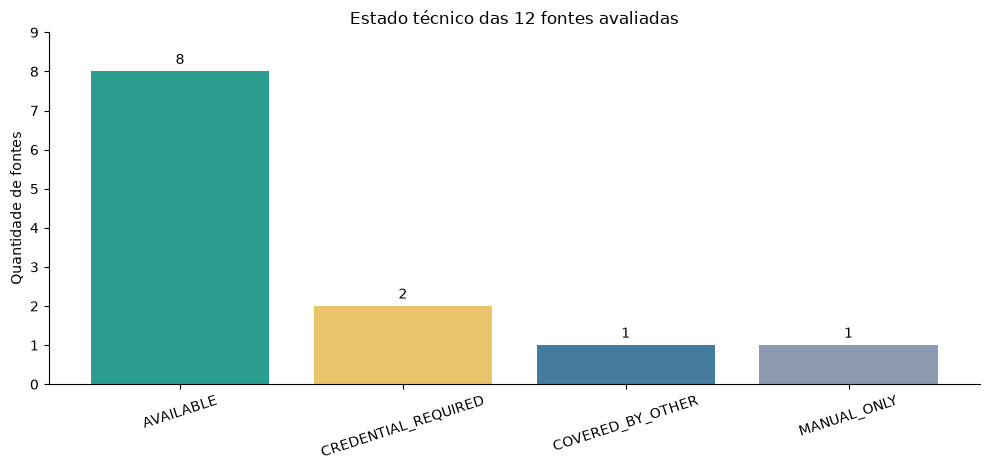

Resumo: {'AVAILABLE': 8, 'CREDENTIAL_REQUIRED': 2, 'COVERED_BY_OTHER': 1, 'MANUAL_ONLY': 1}


In [4]:
status_order = [
    SourceProbeStatus.AVAILABLE,
    SourceProbeStatus.CREDENTIAL_REQUIRED,
    SourceProbeStatus.COVERED_BY_OTHER,
    SourceProbeStatus.MANUAL_ONLY,
    SourceProbeStatus.NO_RESULTS,
    SourceProbeStatus.ERROR,
]
counts = Counter(item.status for item in report.results)
labels = [status.value for status in status_order if counts[status]]
values = [counts[status] for status in status_order if counts[status]]
colors = {
    SourceProbeStatus.AVAILABLE: "#2a9d8f",
    SourceProbeStatus.CREDENTIAL_REQUIRED: "#e9c46a",
    SourceProbeStatus.COVERED_BY_OTHER: "#457b9d",
    SourceProbeStatus.MANUAL_ONLY: "#8d99ae",
    SourceProbeStatus.NO_RESULTS: "#f4a261",
    SourceProbeStatus.ERROR: "#e63946",
}

fig, ax = plt.subplots(figsize=(10, 4.8))
bars = ax.bar(
    labels,
    values,
    color=[colors[status] for status in status_order if counts[status]],
)
ax.bar_label(bars, padding=3)
ax.set_title("Estado técnico das 12 fontes avaliadas")
ax.set_ylabel("Quantidade de fontes")
ax.set_ylim(0, max(values) + 1)
ax.tick_params(axis="x", rotation=18)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print("Resumo:", {label: value for label, value in zip(labels, values)})

### 4. Separar busca, conteúdo e validação

A fonte precisa entrar no lugar correto do pipeline. Uma retratação no Crossref não é um artigo adicional; um texto no PMC não é um estudo independente do registro correspondente no PubMed.

In [5]:
by_role = Counter(item.role for item in report.results)
role_rows = "".join(
    f"<tr><td>{role.value}</td><td>{count}</td><td>"
    + ", ".join(escape(item.source) for item in report.results if item.role is role)
    + "</td></tr>"
    for role, count in sorted(by_role.items(), key=lambda value: value[0].value)
)
display(HTML(
    "<table><thead><tr><th>Papel</th><th>Quantidade</th><th>Fontes</th></tr></thead>"
    f"<tbody>{role_rows}</tbody></table>"
))

Papel,Quantidade,Fontes
CONTENT,1,PubMed Central (PMC)
DISCOVERY,3,"PubMed, OpenAlex, SciELO"
MANUAL,1,Google Acadêmico
PUBLISHER,3,"Springer Nature, ScienceDirect, Nature"
VALIDATION,4,"ClinicalTrials.gov, Crossref, Retraction Watch (via Crossref), DataCite"


## Checks

As verificações impedem que uma plataforma editorial ou uma busca manual seja apresentada como fonte automática independente. Também exigem resposta das fontes abertas essenciais durante esta execução.

In [6]:
by_source = {item.source: item for item in report.results}
expected_sources = {
    "PubMed", "PubMed Central (PMC)", "ClinicalTrials.gov", "Crossref",
    "Retraction Watch (via Crossref)", "OpenAlex", "DataCite", "SciELO",
    "Springer Nature", "ScienceDirect", "Nature", "Google Acadêmico",
}
required_open_sources = {
    "PubMed", "PubMed Central (PMC)", "ClinicalTrials.gov", "Crossref",
    "Retraction Watch (via Crossref)", "OpenAlex", "DataCite", "SciELO",
}

assert set(by_source) == expected_sources
assert all(by_source[name].status is SourceProbeStatus.AVAILABLE for name in required_open_sources)
assert by_source["Nature"].status is SourceProbeStatus.COVERED_BY_OTHER
assert by_source["Google Acadêmico"].status is SourceProbeStatus.MANUAL_ONLY
assert by_source["SciELO"].query_specific is False
assert report.error_count == 0
print("As 12 fontes foram classificadas e as 8 integrações abertas responderam sem erro.")

As 12 fontes foram classificadas e as 8 integrações abertas responderam sem erro.


## Takeaways

- A infraestrutura aberta necessária para ampliar a busca está acessível: PubMed, OpenAlex e o catálogo SciELO responderam.
- PMC, ClinicalTrials.gov, Crossref/Retraction Watch e DataCite devem continuar como conteúdo e validação, sem aumentar artificialmente a contagem de estudos.
- Springer Nature e ScienceDirect ficaram pendentes de credenciais; isso é uma limitação de acesso conhecida, não falha silenciosa.
- Nature é coberta como plataforma editorial e Google Acadêmico permanece como conferência manual.
- O próximo passo é implementar a **busca federada e deduplicação por DOI, PMID e metadados**, medindo quantos resultados únicos OpenAlex e SciELO realmente acrescentam ao PubMed.

Este teste confirma disponibilidade técnica na data da execução. Não demonstra cobertura completa, relevância clínica nem independência entre catálogos.